In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

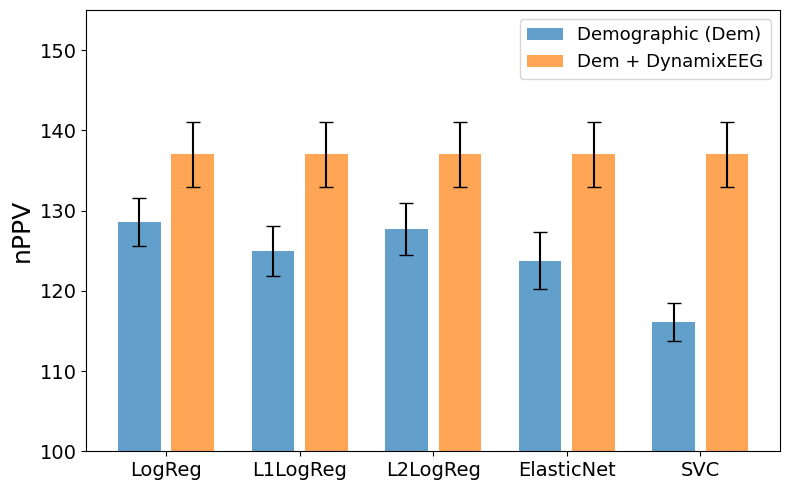

In [ ]:
ticksize = 14
barlabelsize = 14
labelsize = 18

# DEMOGRAPHIC-ONLY PLOT
# load data
df = pd.read_csv('../data/demographics_only_1/scores.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = np.array([col.replace('_test_score', '') for col in test_cols])

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder

desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
short_names =   ['LogReg', 'L1LogReg', 'L2LogReg', 'ElasticNet', 'SVC']

order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    models[idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 5))
pad = 0.5
xpos = np.arange(0, 5) * 2.5
bar1_xpos = xpos - pad
bar2_xpos = xpos + pad

bars1 = plt.bar(bar1_xpos, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7, label='Demographic (Dem)')
bars2 = plt.bar(bar2_xpos, np.repeat(137, 5).tolist(), yerr=np.repeat(4, 5).tolist(), capsize=5, alpha=0.7, label='Dem + DynamixEEG')

# plt.xlabel('Models', fontsize=labelsize)
plt.ylabel('nPPV', fontsize=labelsize)
plt.xticks(xpos, short_names, fontsize=barlabelsize)
plt.yticks(fontsize=ticksize)
plt.ylim(100, 155)
plt.tight_layout()
plt.legend(fontsize=legendsize)
plt.savefig('../figures/demographic_barplot.svg')